In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read Excel file
all_sheets = pd.read_excel('Analysis_v2.xlsx', sheet_name=None)


In [3]:
df_sgt = all_sheets['SGT Descriptors']
df_sgt.columns = df_sgt.iloc[0]
df_sgt = df_sgt[1:]
df_sgt = df_sgt.dropna(axis=1)
df_sgt

,Material,Parameter,Value-1,Value-2,Value-3,Value-4,Avg.,Std. Dev.
1,BSE 017,Nodes,7785,7763,7787,7773,7777,11.195237
2,BSE 017,Edges,13854,13792,13844,13788,13819.5,34.346276
3,BSE 017,ND,3.55915,3.55327,3.55567,3.54766,3.553937,0.004831
4,BSE 017,Diameter,111,111,116,116,113.5,2.886751
5,BSE 017,GD,0.00046,0.00046,0.00046,0.00046,0.00046,0
6,BSE 017,BC,0.00518,0.0052,0.00517,0.0052,0.005188,0.000015
7,BSE 017,EC,0.00135,0.00135,0.00135,0.00135,0.00135,0
8,BSE 017,CC,0.02481,0.02478,0.02484,0.02479,0.024805,0.000026
9,BSE 025,Nodes,7329,7320,7360,7355,7341,19.510681
10,BSE 025,Edges,12000,12036,12052,12088,12044,36.514837


In [4]:
# Filter the relevant materials and parameters
materials = ['BSE 017', 'BSE 011', 'BSE 024', 'BSE 025']
parameters = ['Nodes', 'Edges', 'ND', 'Diameter', 'GD', 'BC', 'EC']

# Filter and pivot
# filtered_df = df_sgt[df_sgt['Material'].isin(materials) & df_sgt['Parameter'].isin(parameters)]
pivot_avg = df_sgt.pivot(index='Material', columns='Parameter', values='Avg.')
pivot_std = df_sgt.pivot(index='Material', columns='Parameter', values='Std. Dev.')

# Ensure consistent parameter order
pivot_avg = pivot_avg[parameters]
pivot_std = pivot_std[parameters]

#print(filtered_df)
print(f"Avg Table:\n{pivot_avg}\n\nStd. Dev Table:\n{pivot_std}")

Avg Table:
Parameter   Nodes    Edges        ND Diameter       GD        BC        EC
Material                                                                  
BSE 011    7452.5  13942.5  3.741702    98.75   0.0005   0.00493  0.000902
BSE 017      7777  13819.5  3.553937    113.5  0.00046  0.005188   0.00135
BSE 024    7763.5  13755.5   3.54363   113.75  0.00046  0.005282   0.00127
BSE 025      7341    12044    3.2813   117.25  0.00045  0.005873   0.00087

Std. Dev Table:
Parameter      Nodes      Edges        ND  Diameter GD        BC        EC
Material                                                                  
BSE 011     18.35756  26.901053   0.00427       0.5  0  0.000018  0.000005
BSE 017    11.195237  34.346276  0.004831  2.886751  0  0.000015         0
BSE 024     9.146948  34.837719  0.004855  0.957427  0   0.00001         0
BSE 025    19.510681  36.514837  0.007497  2.061553  0  0.000021  0.000069


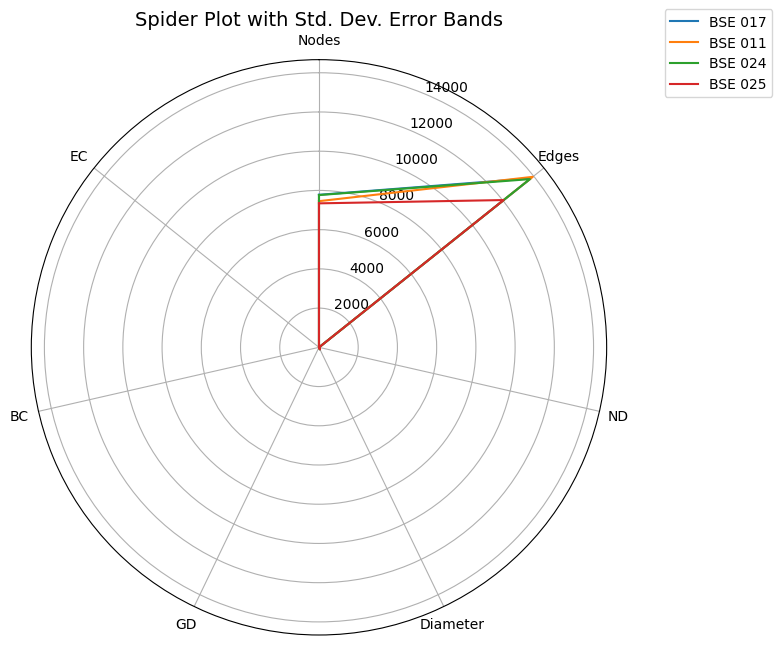

In [5]:
# Radar chart setup
labels = parameters
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
labels += [labels[0]]  # close the loop
angles += [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each material
for mat in materials:
    values = pivot_avg.loc[mat].tolist()
    values += [values[0]]  # close the loop

    errors = pivot_std.loc[mat].tolist()
    errors += [errors[0]]

    ax.plot(angles, values, label=mat)
    ax.fill_between(angles,
                    np.array(values) - np.array(errors),
                    np.array(values) + np.array(errors),
                    alpha=0.1)

# Final touches
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels[:-1])
ax.set_title("Spider Plot with Std. Dev. Error Bands", fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [6]:
def power_law_function(x, a, k):
    """
        A best-fit model that follows the power law distribution: y = a * x^(-k),
        where a and k are fitting parameters.

        Args:
            x (np.array): Array of x values
            a (float): intercept or scale factor/constant (shifts curve up/down). It does not affect the shape/decay rate of the curve (only how high the curve starts)
            k (float): exponent of the power law distribution. It defines how fast y decays as x increases.
    """
    return a * x ** (-k)

In [7]:
# we define x 100 values from a range of 0-1000
x_vals = np.linspace(0, 1000, 100)

In [8]:
for sheet_name, df_scl in all_sheets.items():
    df_scl.columns = df_scl.iloc[0]
    df_scl = df_scl[1:]
    df_scl = df_scl.dropna(axis=1)


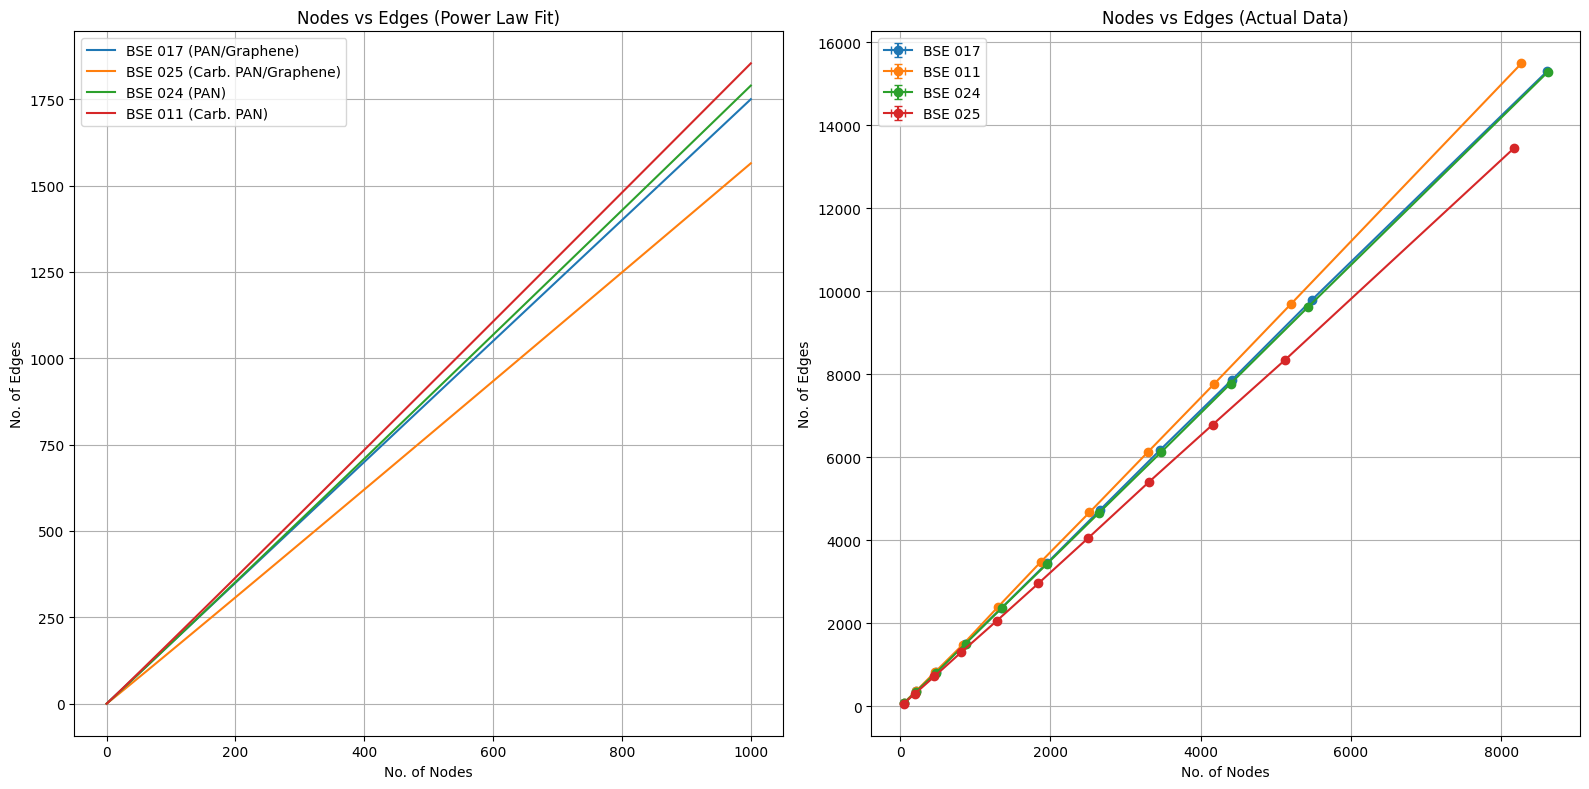

In [9]:
"""
No. Edges
"""
df_edges = all_sheets['Nodes-Edges']
data = np.loadtxt('edges.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Edges (Power Law Fit)")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("No. of Edges")
ax1.plot(x_vals, y1, label=f"BSE 017 (PAN/Graphene)")
ax1.plot(x_vals, y2, label=f"BSE 025 (Carb. PAN/Graphene)")
ax1.plot(x_vals, y3, label=f"BSE 024 (PAN)")
ax1.plot(x_vals, y4, label=f"BSE 011 (Carb. PAN)")
ax1.legend()
plt.grid(True)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for sample in materials:
    df_sample = df_edges[df_edges['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=sample,
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('No. of Edges')
ax2.set_title('Nodes vs Edges (Actual Data)')
ax2.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

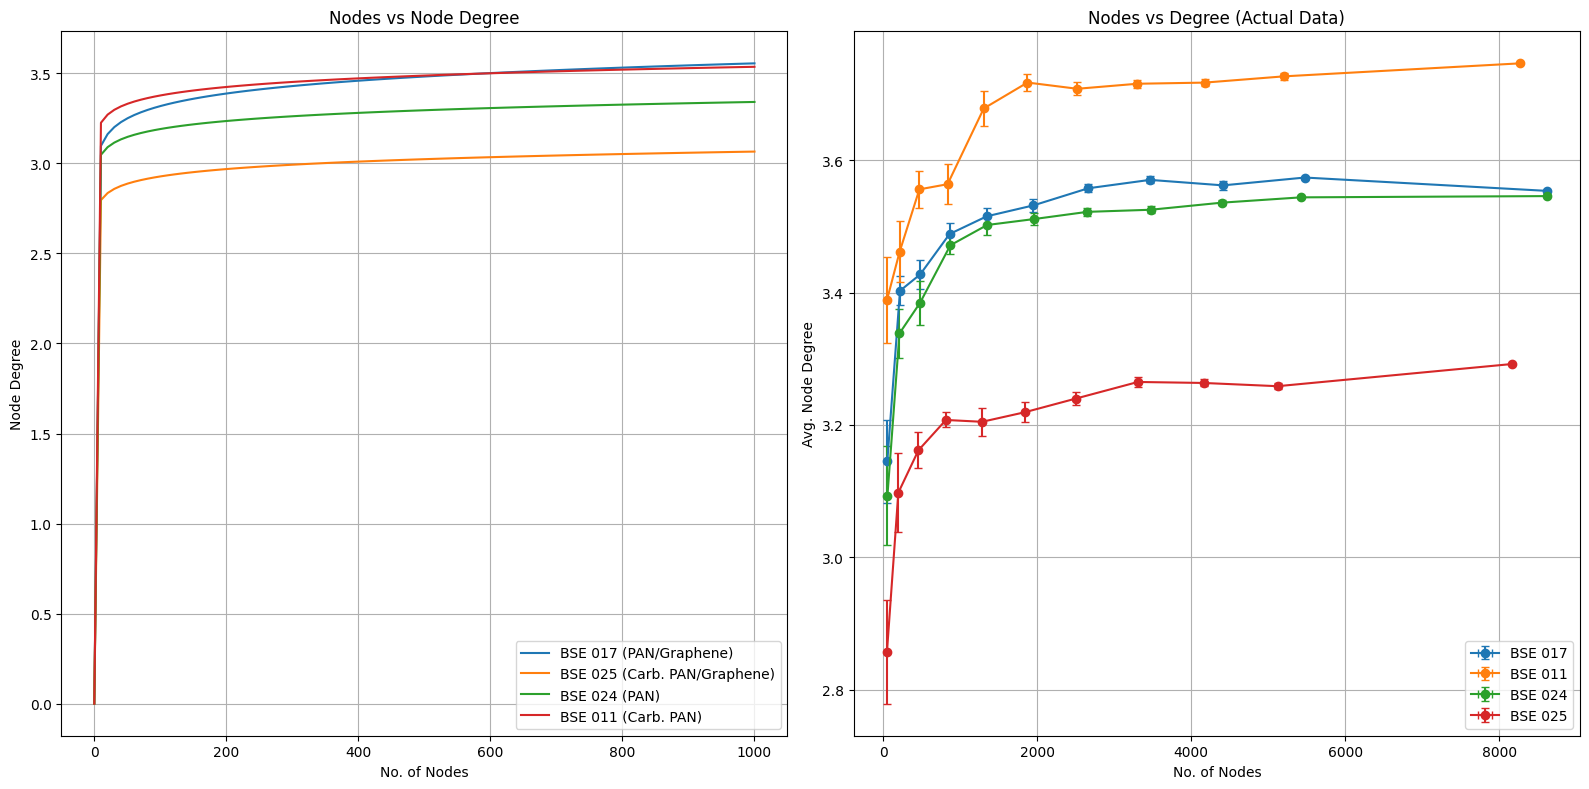

In [10]:
"""
Node Degree
"""
df_deg = all_sheets['Nodes-Degree']
data = np.loadtxt('degree.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Node Degree")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Node Degree")
ax1.plot(x_vals, y1, label=f"BSE 017 (PAN/Graphene)")
ax1.plot(x_vals, y2, label=f"BSE 025 (Carb. PAN/Graphene)")
ax1.plot(x_vals, y3, label=f"BSE 024 (PAN)")
ax1.plot(x_vals, y4, label=f"BSE 011 (Carb. PAN)")
ax1.legend()
plt.grid(True)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for sample in materials:
    df_sample = df_deg[df_deg['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=sample,
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Node Degree')
ax2.set_title('Nodes vs Degree (Actual Data)')
ax2.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\owuor\AppData\Local\Temp\1\ipykernel_29348\2429440888.py:11: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-k)


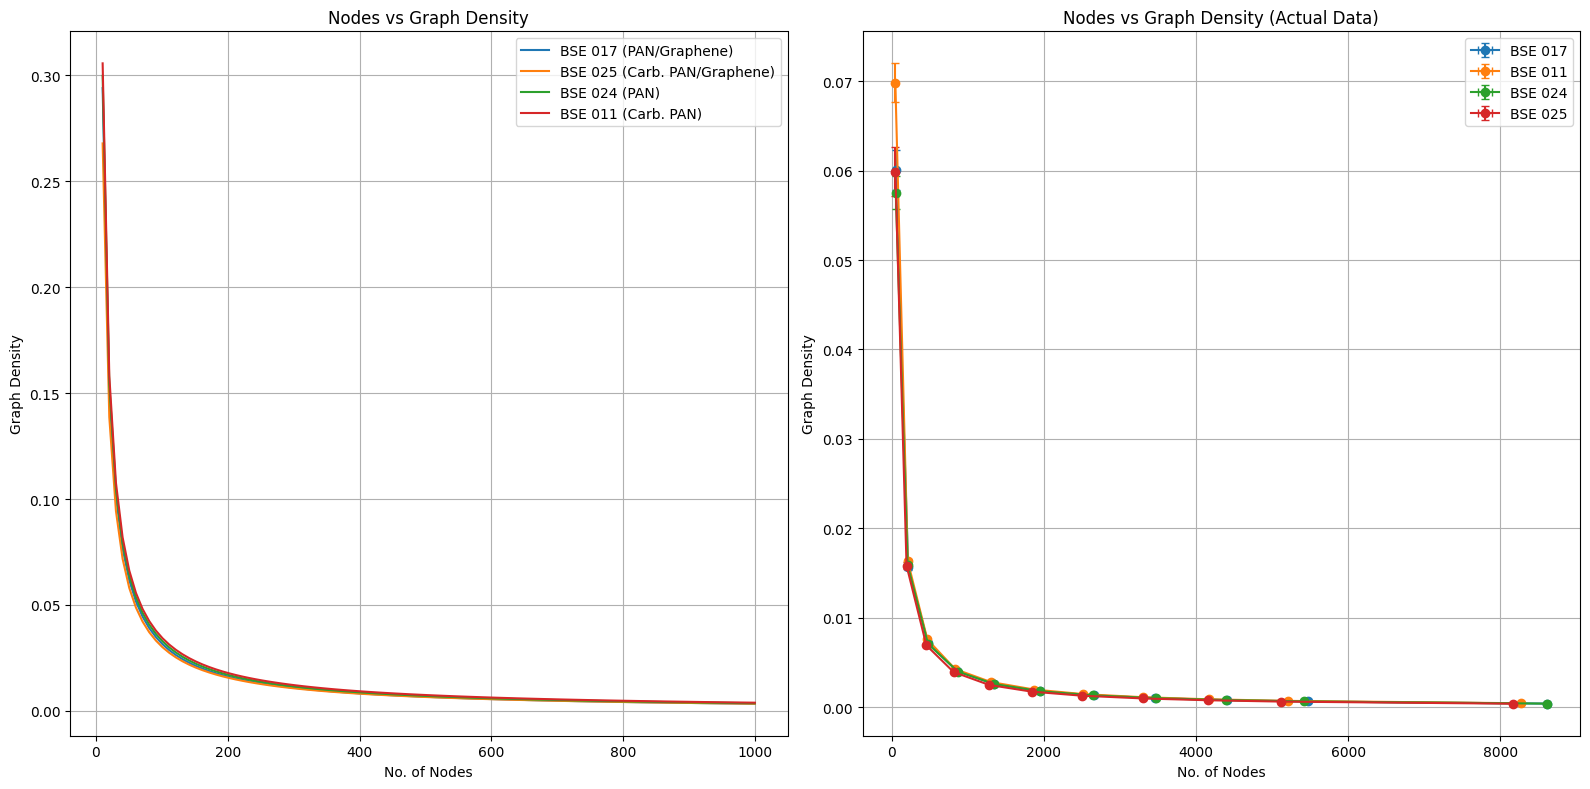

In [11]:
"""
Graph Density
"""
df_dens = all_sheets['Nodes-G. Density']
data = np.loadtxt('density.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Graph Density")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Graph Density")
ax1.plot(x_vals, y1, label=f"BSE 017 (PAN/Graphene)")
ax1.plot(x_vals, y2, label=f"BSE 025 (Carb. PAN/Graphene)")
ax1.plot(x_vals, y3, label=f"BSE 024 (PAN)")
ax1.plot(x_vals, y4, label=f"BSE 011 (Carb. PAN)")
ax1.legend()
plt.grid(True)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for sample in materials:
    df_sample = df_dens[df_dens['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=sample,
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Graph Density')
ax2.set_title('Nodes vs Graph Density (Actual Data)')
ax2.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\owuor\AppData\Local\Temp\1\ipykernel_29348\2429440888.py:11: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-k)


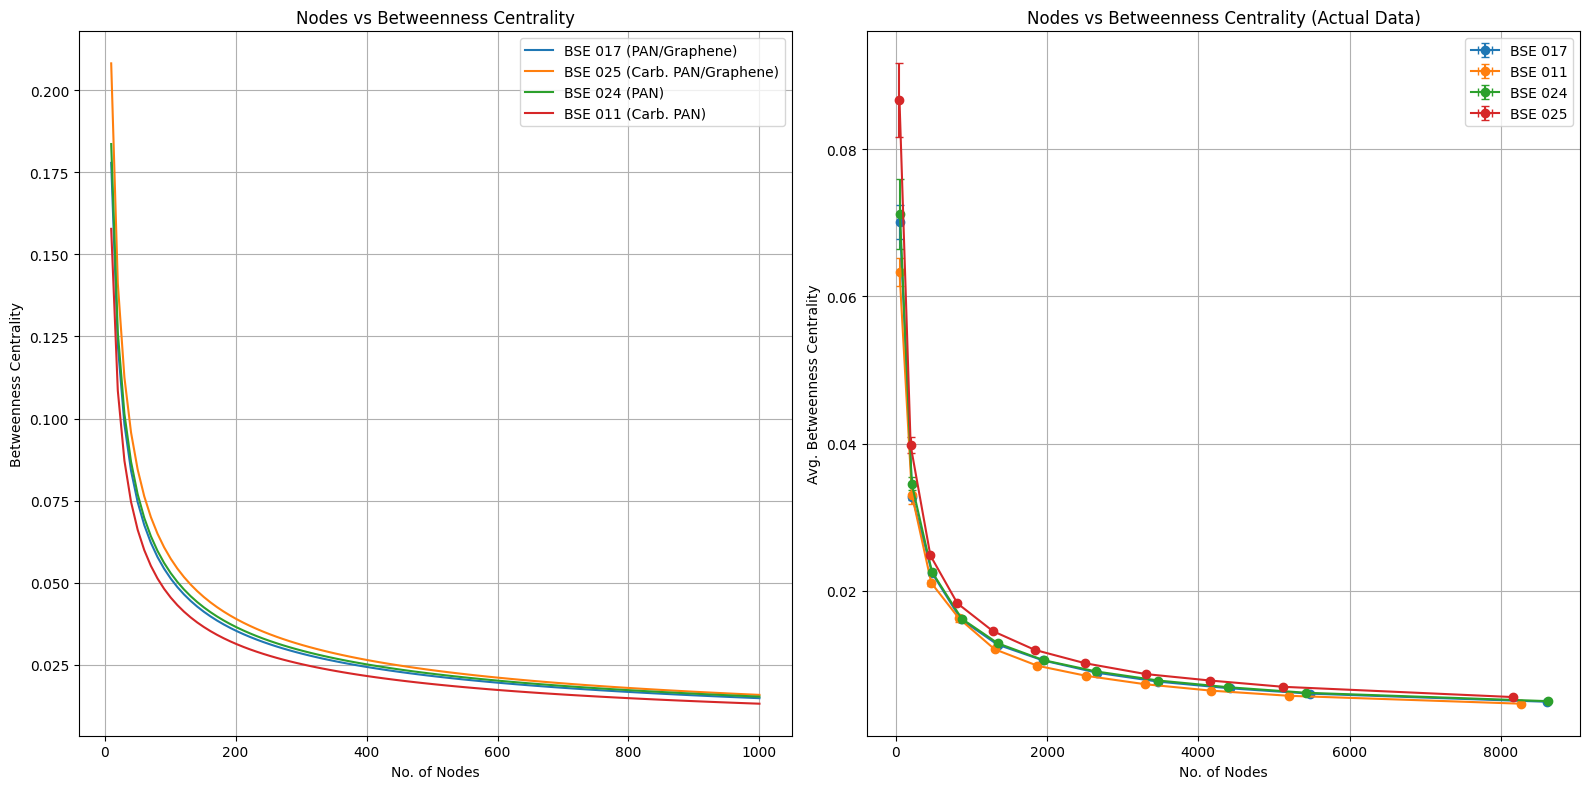

In [12]:
"""
Betweenness
"""
df_betwn = all_sheets['Nodes-Avg. Btwn. C']
data = np.loadtxt('betweenness.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Betweenness Centrality")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Betweenness Centrality")
ax1.plot(x_vals, y1, label=f"BSE 017 (PAN/Graphene)")
ax1.plot(x_vals, y2, label=f"BSE 025 (Carb. PAN/Graphene)")
ax1.plot(x_vals, y3, label=f"BSE 024 (PAN)")
ax1.plot(x_vals, y4, label=f"BSE 011 (Carb. PAN)")
ax1.legend()
plt.grid(True)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for sample in materials:
    df_sample = df_betwn[df_betwn['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=sample,
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Betweenness Centrality')
ax2.set_title('Nodes vs Betweenness Centrality (Actual Data)')
ax2.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\owuor\AppData\Local\Temp\1\ipykernel_29348\2429440888.py:11: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-k)


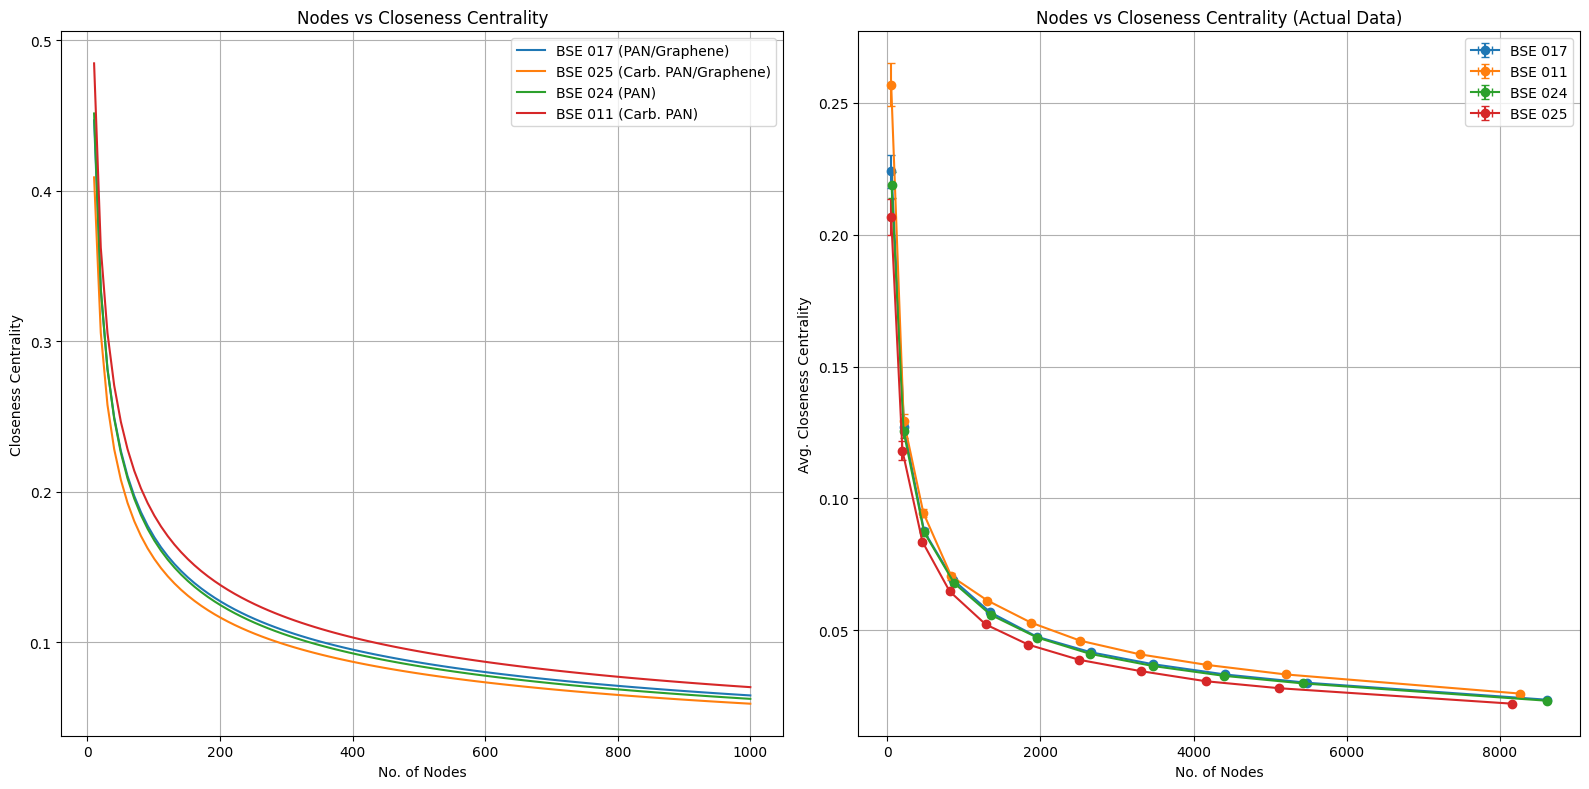

In [13]:
"""
Closeness
"""
df_clo = all_sheets['Nodes-Avg. Close. C']
data = np.loadtxt('closeness.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Closeness Centrality")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Closeness Centrality")
ax1.plot(x_vals, y1, label=f"BSE 017 (PAN/Graphene)")
ax1.plot(x_vals, y2, label=f"BSE 025 (Carb. PAN/Graphene)")
ax1.plot(x_vals, y3, label=f"BSE 024 (PAN)")
ax1.plot(x_vals, y4, label=f"BSE 011 (Carb. PAN)")
ax1.legend()
plt.grid(True)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for sample in materials:
    df_sample = df_clo[df_clo['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=sample,
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Closeness Centrality')
ax2.set_title('Nodes vs Closeness Centrality (Actual Data)')
ax2.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

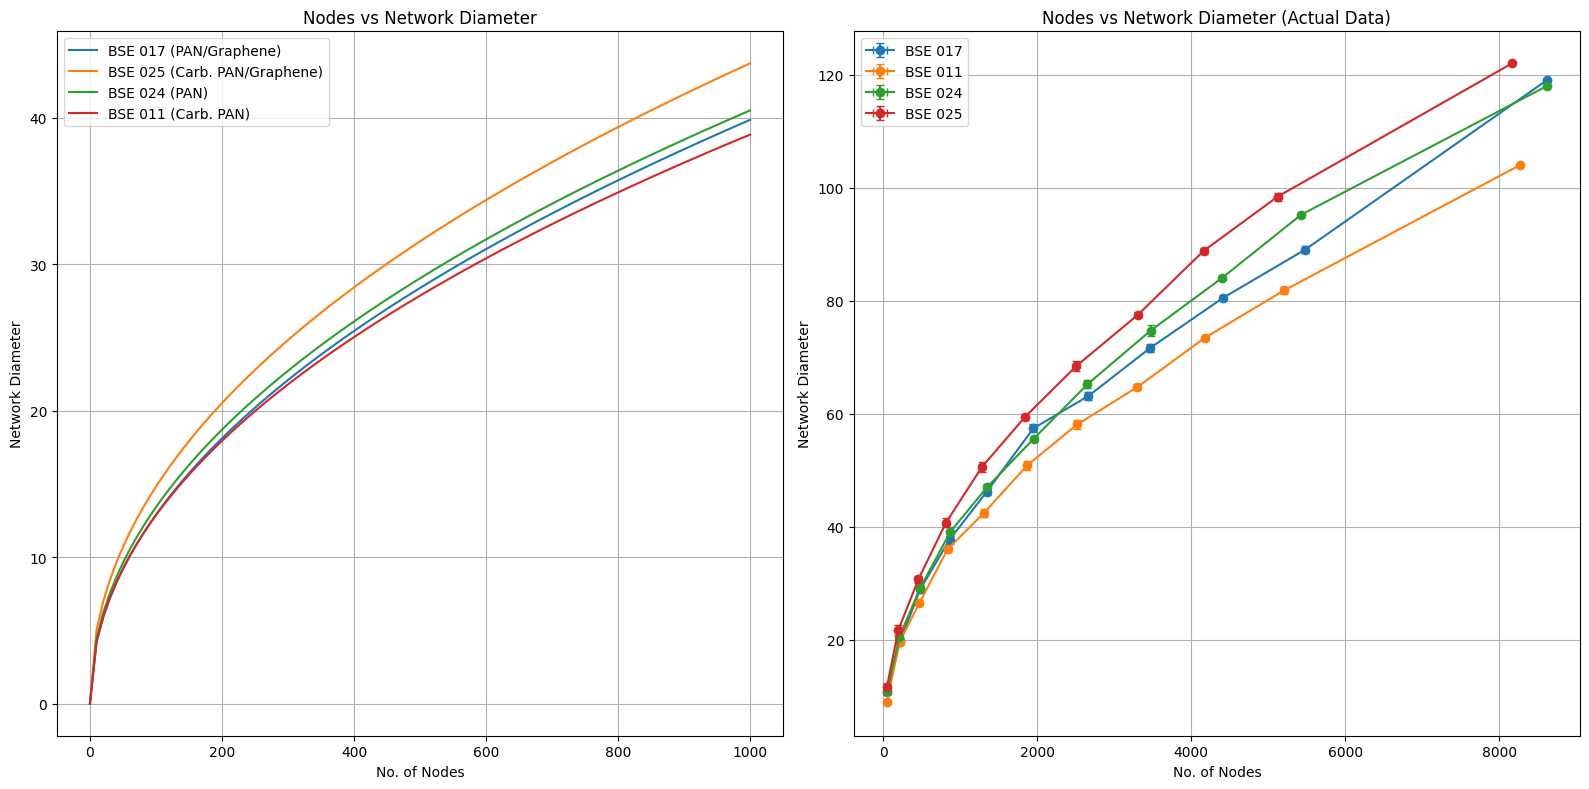

In [14]:
"""
Network Diameter
"""
df_dia = all_sheets['Nodes-Diameter']
data = np.loadtxt('diameter.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Network Diameter")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Network Diameter")
ax1.plot(x_vals, y1, label=f"BSE 017 (PAN/Graphene)")
ax1.plot(x_vals, y2, label=f"BSE 025 (Carb. PAN/Graphene)")
ax1.plot(x_vals, y3, label=f"BSE 024 (PAN)")
ax1.plot(x_vals, y4, label=f"BSE 011 (Carb. PAN)")
ax1.legend()
plt.grid(True)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for sample in materials:
    df_sample = df_dia[df_dia['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=sample,
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Network Diameter')
ax2.set_title('Nodes vs Network Diameter (Actual Data)')
ax2.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\owuor\AppData\Local\Temp\1\ipykernel_29348\2429440888.py:11: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-k)


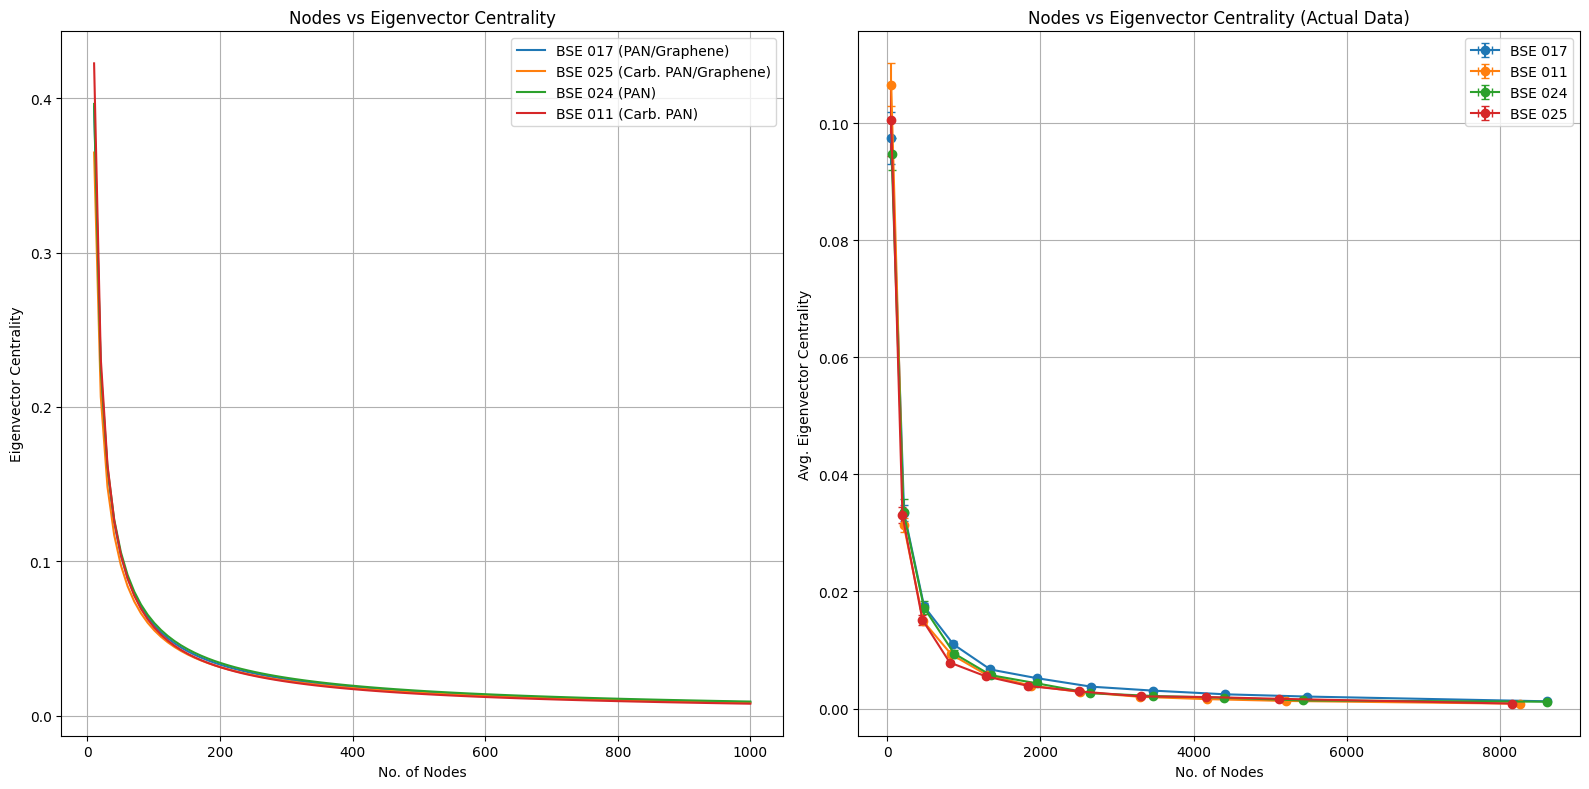

In [15]:
"""
Eigenvector
"""
df_eig = all_sheets['Nodes-Avg. EigVec. C.']
data = np.loadtxt('eigenvec.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Eigenvector Centrality")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Eigenvector Centrality")
ax1.plot(x_vals, y1, label=f"BSE 017 (PAN/Graphene)")
ax1.plot(x_vals, y2, label=f"BSE 025 (Carb. PAN/Graphene)")
ax1.plot(x_vals, y3, label=f"BSE 024 (PAN)")
ax1.plot(x_vals, y4, label=f"BSE 011 (Carb. PAN)")
ax1.legend()
plt.grid(True)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for sample in materials:
    df_sample = df_eig[df_eig['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=sample,
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Eigenvector Centrality')
ax2.set_title('Nodes vs Eigenvector Centrality (Actual Data)')
ax2.legend()
plt.grid(True)
plt.tight_layout()
plt.show()